In [41]:
#Karthick N 
#24BAD055
#Importing libraries
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_curve, auc

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt

In [42]:
df = pd.read_csv("churn_boosting.csv")
print(df.head())

   Tenure  MonthlyCharges    ContractType InternetService  Churn
0      65          105.22        Two year             NaN      0
1      17           75.19  Month-to-month             NaN      0
2      71           76.09        Two year     Fiber optic      0
3      45          107.67        Two year     Fiber optic      0
4       4           60.35        Two year             NaN      0


In [43]:
#Handle Categorical Data
le = LabelEncoder()

df["ContractType"] = le.fit_transform(df["ContractType"])
df["InternetService"] = le.fit_transform(df["InternetService"])

In [44]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X, y)

print(y_res.value_counts())

Churn
0    113
1    113
Name: count, dtype: int64


In [45]:
#Split Data
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [46]:
#Train AdaBoost
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
ada_acc = accuracy_score(y_test, y_pred_ada)

print("AdaBoost Accuracy:", ada_acc)

AdaBoost Accuracy: 1.0


In [47]:
#Train adaboosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
gb_acc = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 1.0


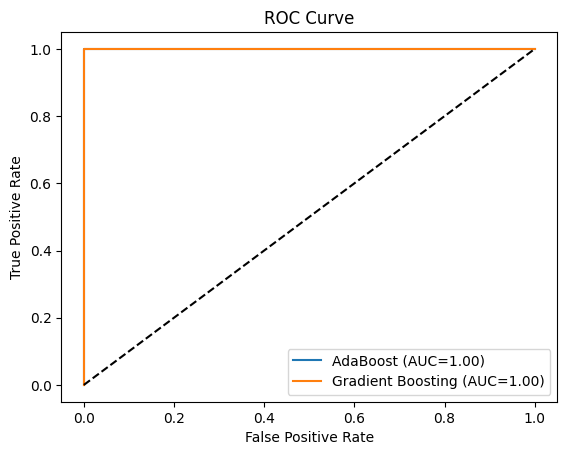

In [48]:
#ROC Curve
# probabilities
y_prob_ada = ada.predict_proba(X_test)[:,1]
y_prob_gb = gb.predict_proba(X_test)[:,1]

# ROC
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_ada = auc(fpr_ada, tpr_ada)
auc_gb = auc(fpr_gb, tpr_gb)

# plot
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC={auc_ada:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC={auc_gb:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

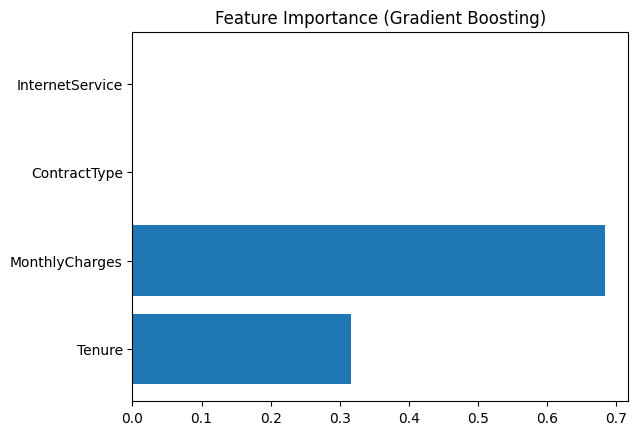

In [49]:
#Feature importance
importances = gb.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

In [50]:
print(df["Churn"].value_counts())

Churn
0    113
1      7
Name: count, dtype: int64
